In [ ]:
import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

path = '/Users/luanabreno/Desktop/Telco.2.0 - Project/'

df_clean = pd.read_parquet(path + '/data_processed/churn_clean.parquet')

In [3]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customerID         7043 non-null   object  
 1   gender             7043 non-null   object  
 2   SeniorCitizen      7043 non-null   int64   
 3   Partner            7043 non-null   object  
 4   Dependents         7043 non-null   object  
 5   tenure             7043 non-null   int64   
 6   PhoneService       7043 non-null   object  
 7   MultipleLines      7043 non-null   object  
 8   InternetService    7043 non-null   object  
 9   OnlineSecurity     7043 non-null   object  
 10  OnlineBackup       7043 non-null   object  
 11  DeviceProtection   7043 non-null   object  
 12  TechSupport        7043 non-null   object  
 13  StreamingTV        7043 non-null   object  
 14  StreamingMovies    7043 non-null   object  
 15  Contract           7043 non-null   object  
 16  Paperl

In [23]:
model_df = df_clean.drop(columns=
                         ['Churn',
                         'high-risk',
                         'risk_score_manual',
                         'risk_segment',
                         'customerID',
                         'risk_score'
                         ], axis=1)

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = model_df.select_dtypes(include='object').columns

for col in cat_cols:
    model_df[col] = le.fit_transform(model_df[col])

print("Categorical columns encoded:", list(cat_cols))
print(f"Final shape: {model_df.shape}")
print(model_df.dtypes)

Categorical columns encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Final shape: (7043, 20)
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn_bin             int64
dtype: object


In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression

X = model_df.drop('Churn_bin', axis=1)
y = model_df['Churn_bin'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

baseline = LogisticRegression(max_iter=5000, random_state=42)
baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)
pred_prob = baseline.predict_proba(X_test)[:,1]

print(f'Accuracy Baseline: {accuracy_score(y_test, pred):.3f}')
print(f'AUC Baseline: {roc_auc_score(y_test, pred_prob):.3f}')


Accuracy Baseline: 0.801
AUC Baseline: 0.841


In [27]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handles class imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [35]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"\nAUC-ROC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))


AUC-ROC: 0.8415

Classification Report:
              precision    recall  f1-score   support

    Retained       0.90      0.75      0.82      1035
     Churned       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



## The model identify approximately 77% of the high risk of churn clients.

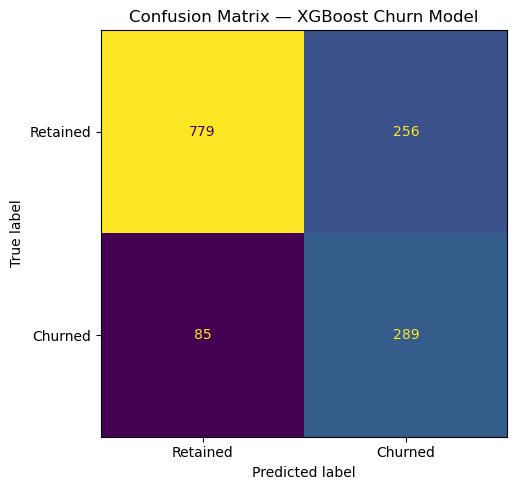

In [36]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Retained', 'Churned'],
    colorbar=False,
    ax=ax
)
ax.set_title('Confusion Matrix — XGBoost Churn Model')
plt.tight_layout()

plt.savefig(path + '/images/confusion_m.png', dpi=150)

# We can save ~$23.000 per month 
### Remember High Risk customers have an average MRR of $79.59 
### The model predicted 289 of the churned clients - 289 x 79.59 = 23.001,51

### I chose threshold = 0.50 (default) to prioritize Precision on the Churned class. In this business context, CS resources are limited and high-confidence churn signals are more actionable than high coverage with noise.

### A lower threshold (0.40) would be recommended if interventions are automated (email campaigns) where cost-per-contact is low.


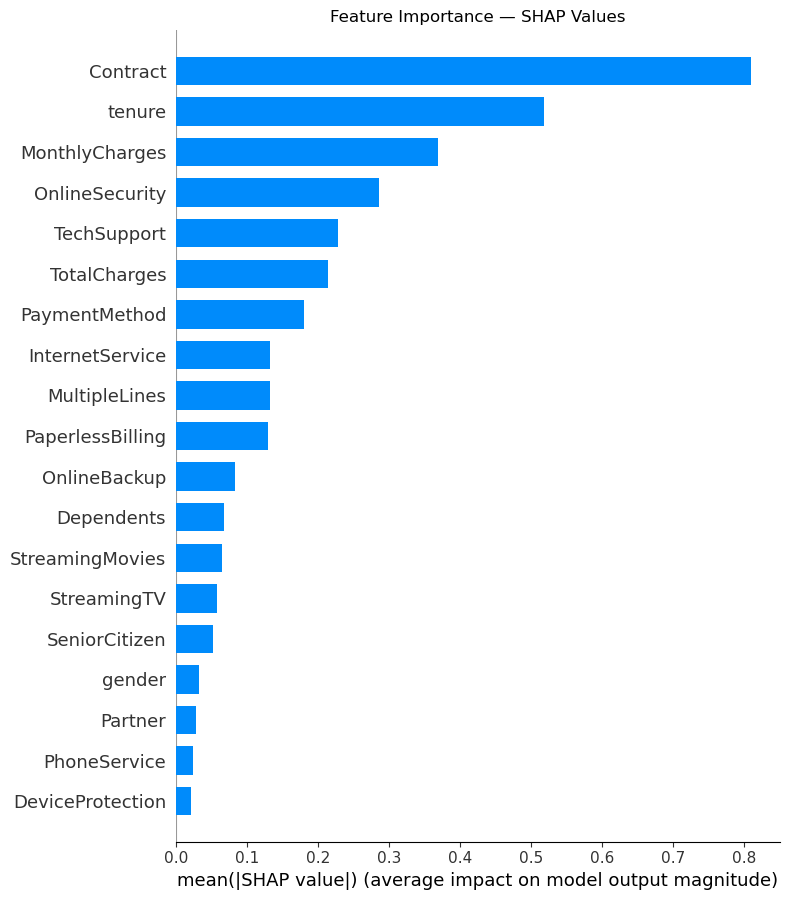

In [37]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# ── Global feature importance — bar plot ────────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    show=False
)
plt.title('Feature Importance — SHAP Values')
plt.tight_layout()
plt.savefig(path + '/images/feat_importance.png', dpi=150)


### The bar plot shows the feature importance.

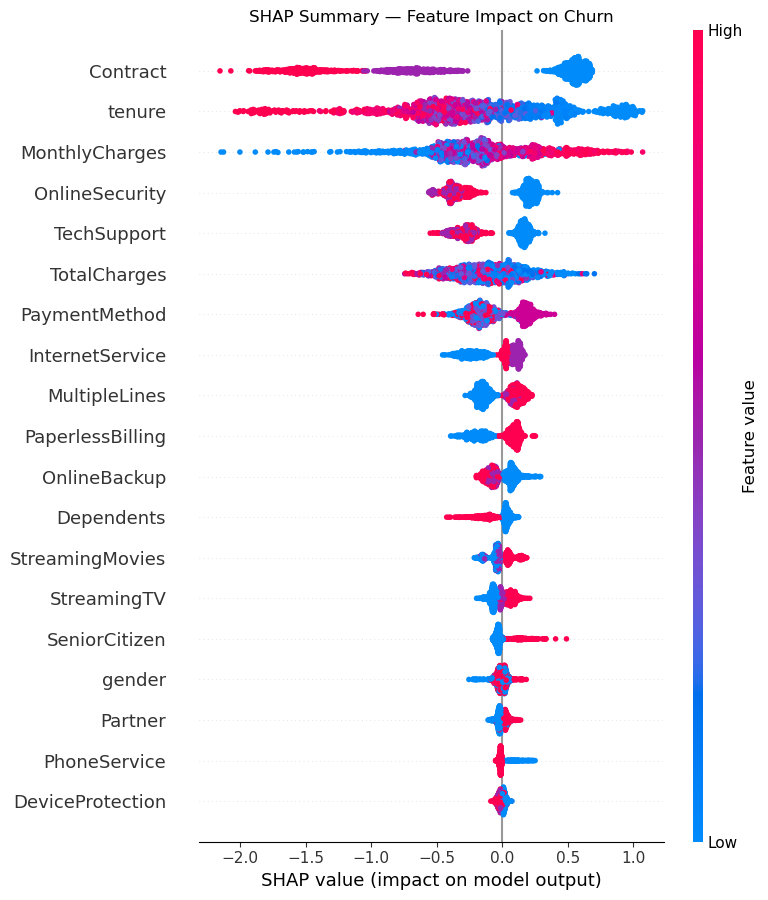

In [38]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary — Feature Impact on Churn')
plt.tight_layout()
plt.savefig(path + '/images/shap_summary.png', dpi=150)

## Key Insights — SHAP Analysis

The XGBoost model (AUC-ROC: 0.84) confirms and ranks the churn drivers
identified during EDA:

1. **Contract type** is the single most powerful predictor — month-to-month
   customers are significantly more likely to churn than annual subscribers.

2. **Tenure** is the second strongest signal — customers in their first
   12 months carry the highest churn risk. Early engagement is critical.

3. **Monthly charges** amplify risk — high-spend customers on Fiber Optic
   plans churn more, suggesting a perceived value gap at premium price points.

4. **Absence of OnlineSecurity and TechSupport** consistently increases
   churn probability — these add-ons act as retention anchors.

### Business Recommendation
Priority intervention: month-to-month customers with tenure < 12 months,
Fiber Optic service, and no TechSupport — this profile concentrates the
highest churn probability and the highest MRR at risk.